In [2]:
import pandas as pd
import numpy as pd

In [3]:
import drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

# Replace 'your_file_name.csv' with the actual name of your CSV file and its path in Google Drive
file_path = '/content/drive/MyDrive/Deep Learning/01_ANN/all/Data_set/creditcard.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame to confirm it loaded correctly
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
missing=df.isna().sum()

print("missing value analysis:")
print(f'total missing valuees:{missing.sum()}')

missing value analysis:
total missing valuees:0


In [10]:
duplicate = df.duplicated()
print(f'duplicat:{duplicate.sum()}')

if duplicate.sum() > 0:
  df= df.drop_duplicates()
  print(f'new dataset:{df.shape[0]:,}')

duplicat:1081
new dataset:283,726


In [11]:
print('data preprocessing')
print('-'*60)

if 'Hour' in df.columns:
  df.drop('Hour',axis=1,inplace = True)
else:
  print('No hour column')

# separate fatuures and target
X = df.drop('Class',axis=1)
y = df['Class']
print('features shape:',X.shape)
print('target shape:',y.shape)

#target imblance cheak
print(f'\n target imblacen:{y.value_counts()}')


data preprocessing
------------------------------------------------------------
No hour column
features shape: (283726, 30)
target shape: (283726,)

 target imblacen:Class
0    283253
1       473
Name: count, dtype: int64


In [12]:
df.shape

(283726, 31)

<bound method IndexOpsMixin.tolist of Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')>


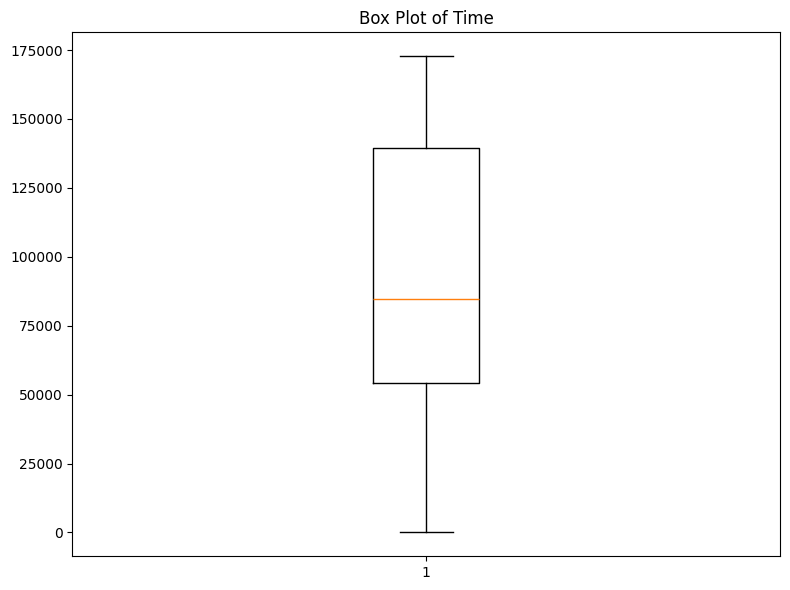

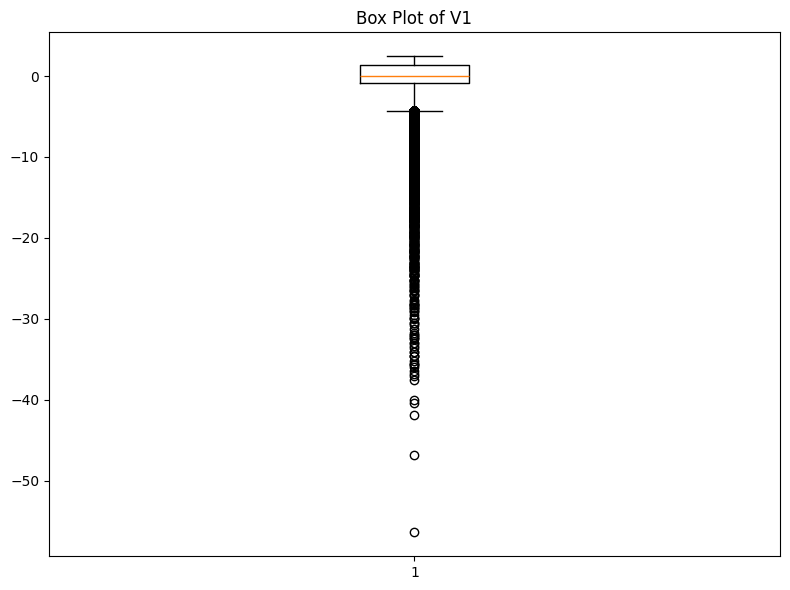

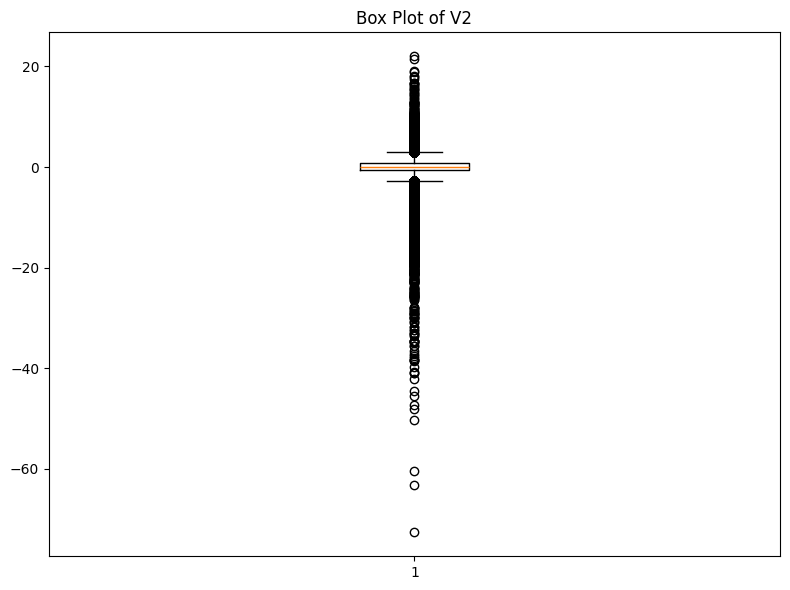

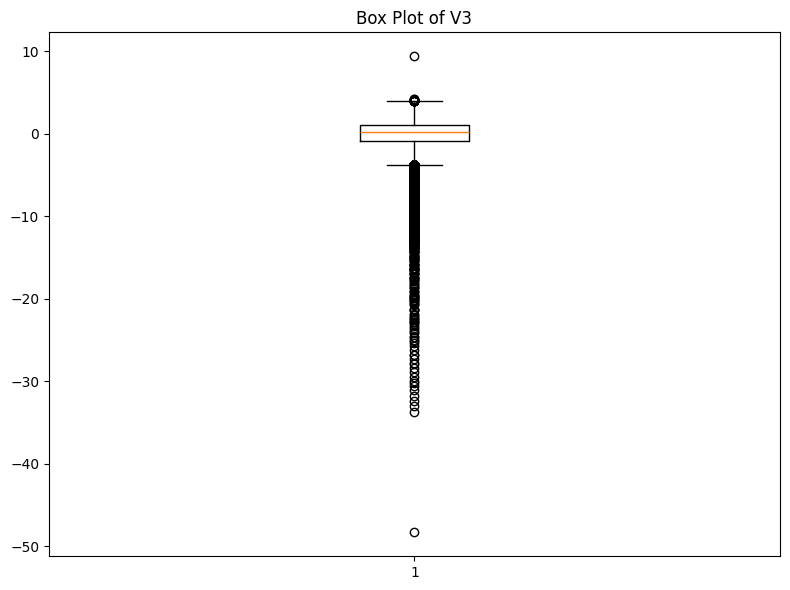

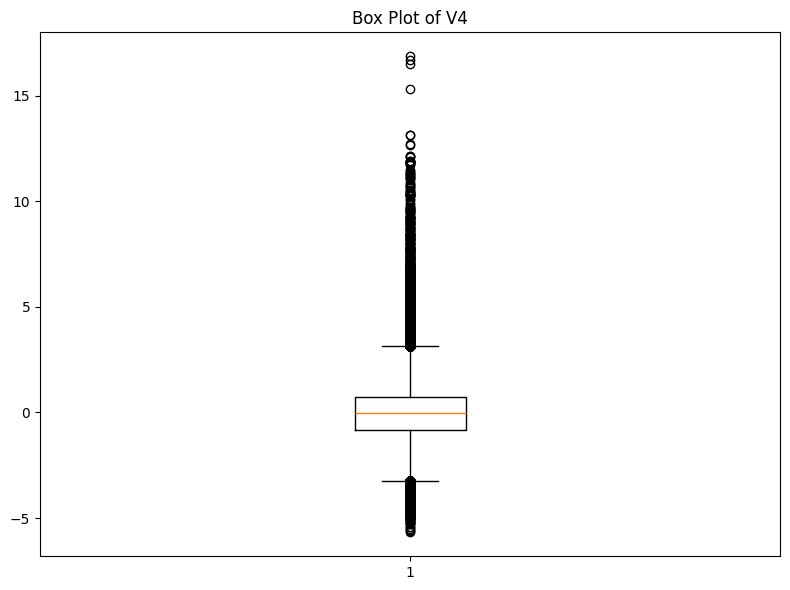

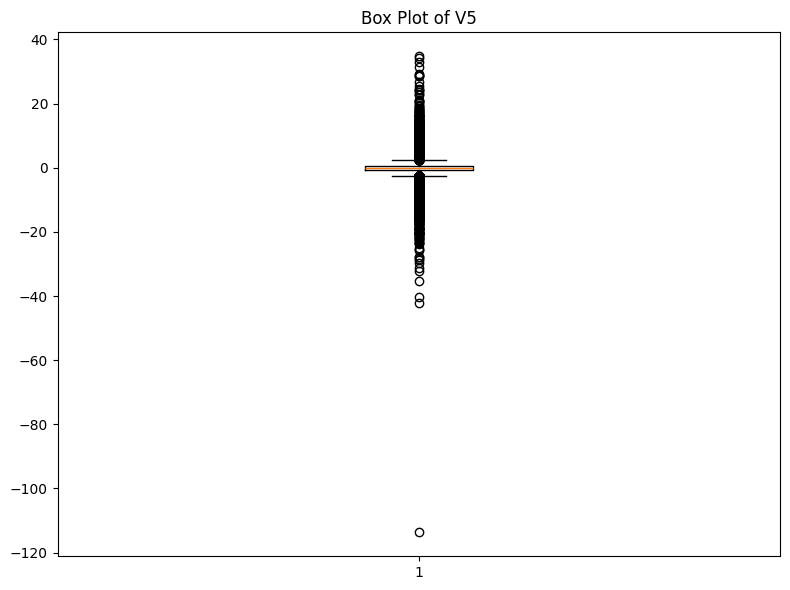

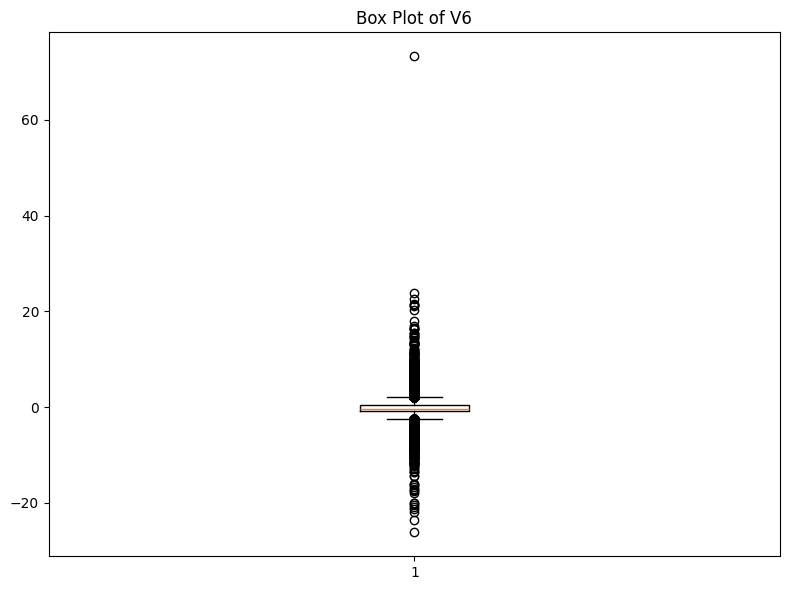

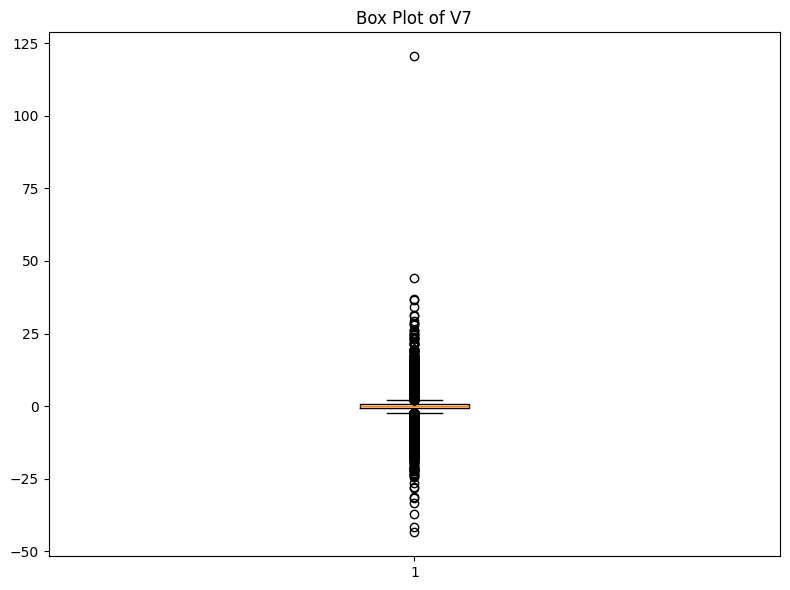

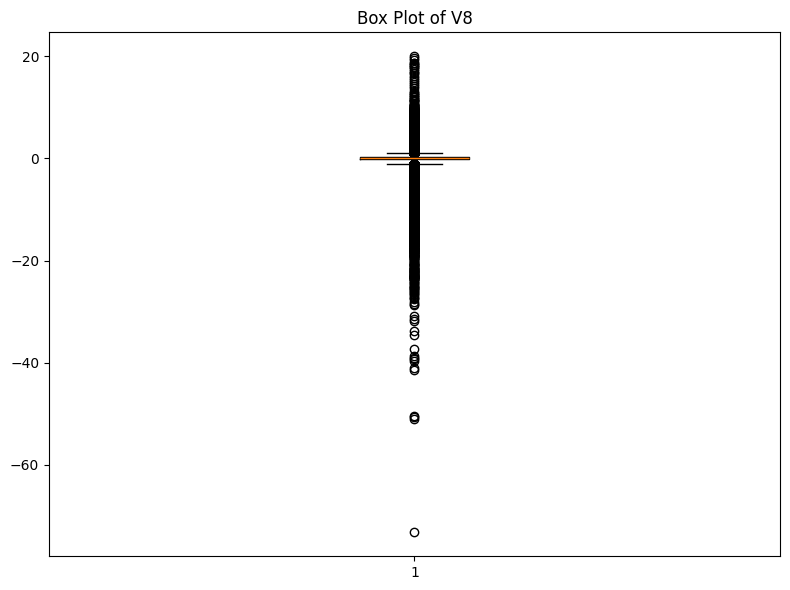

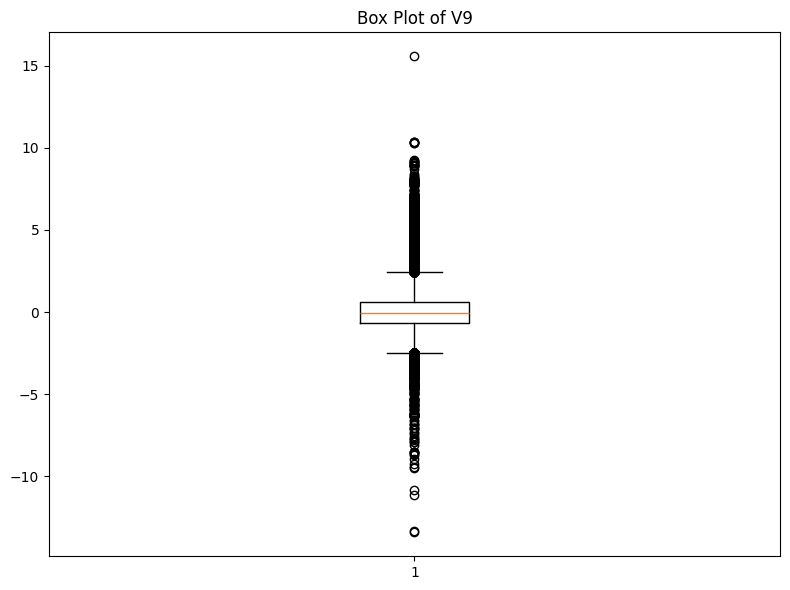

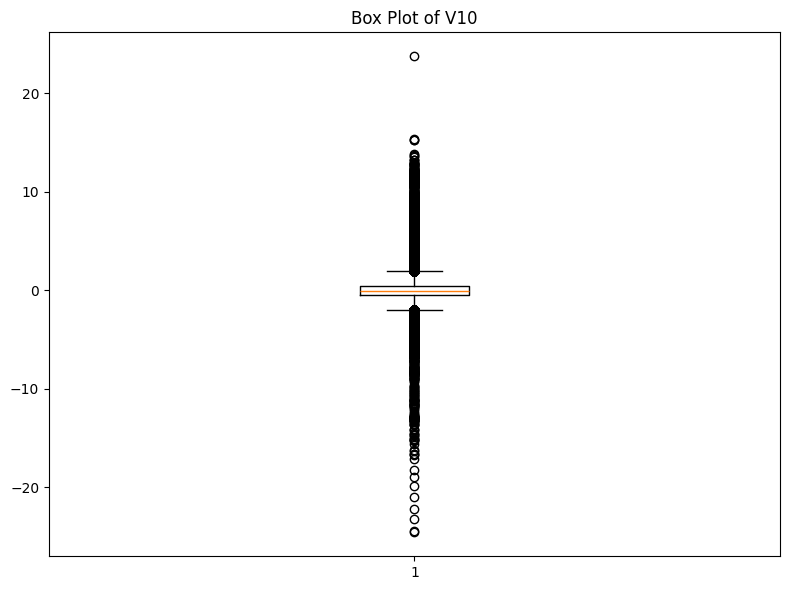

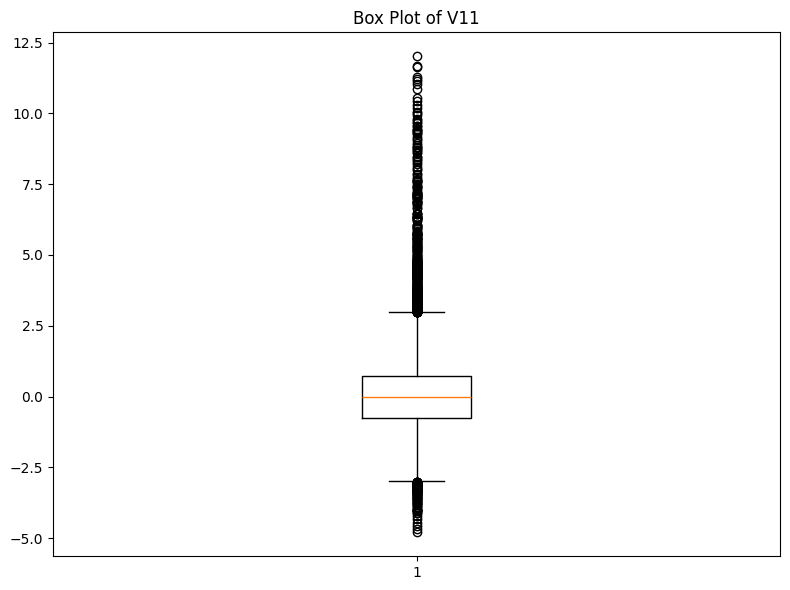

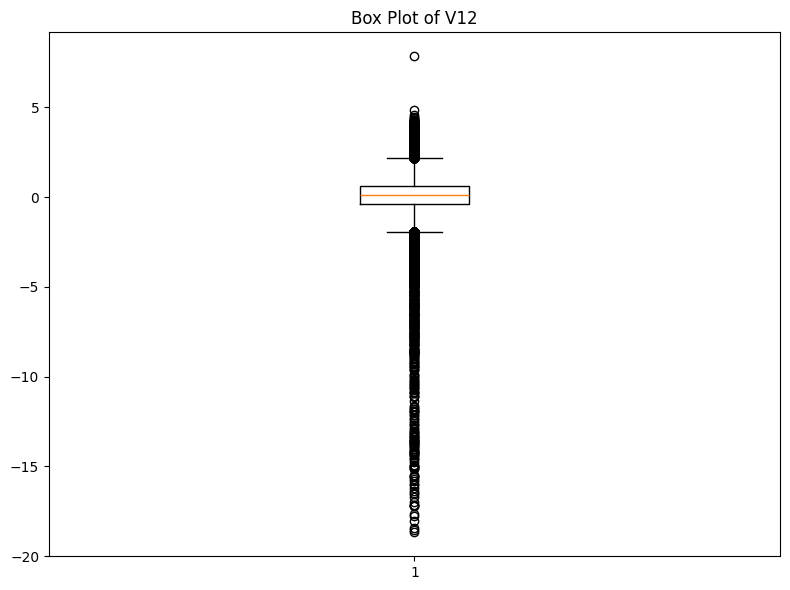

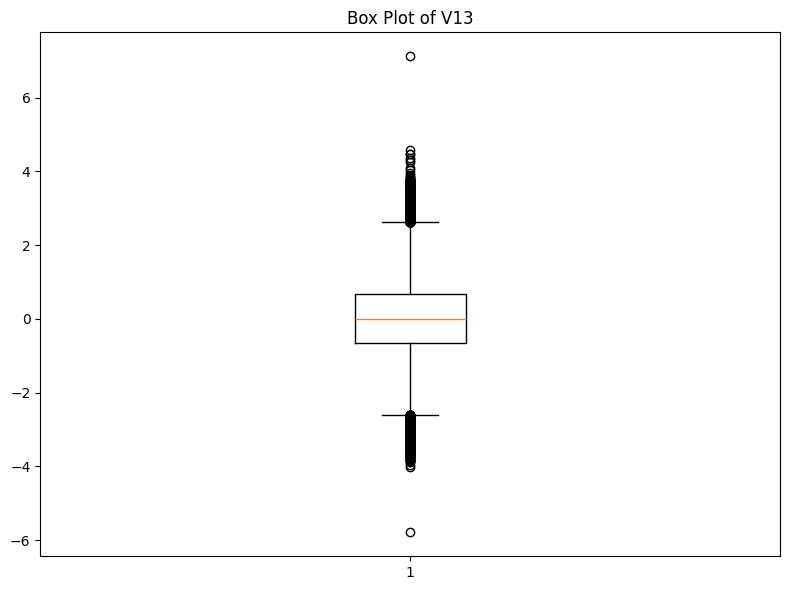

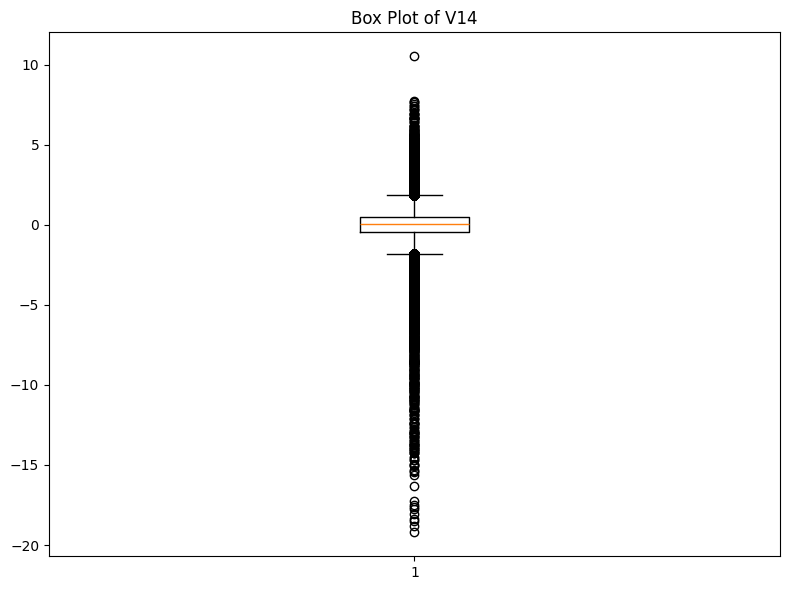

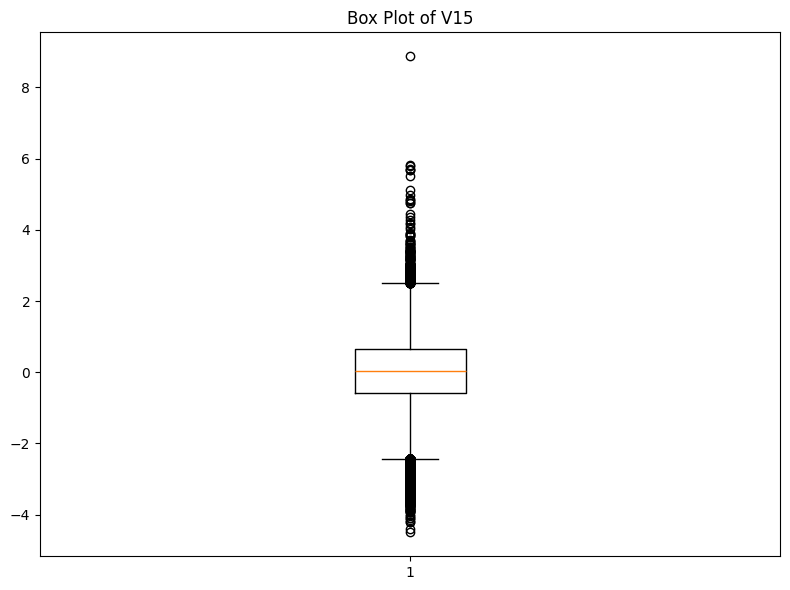

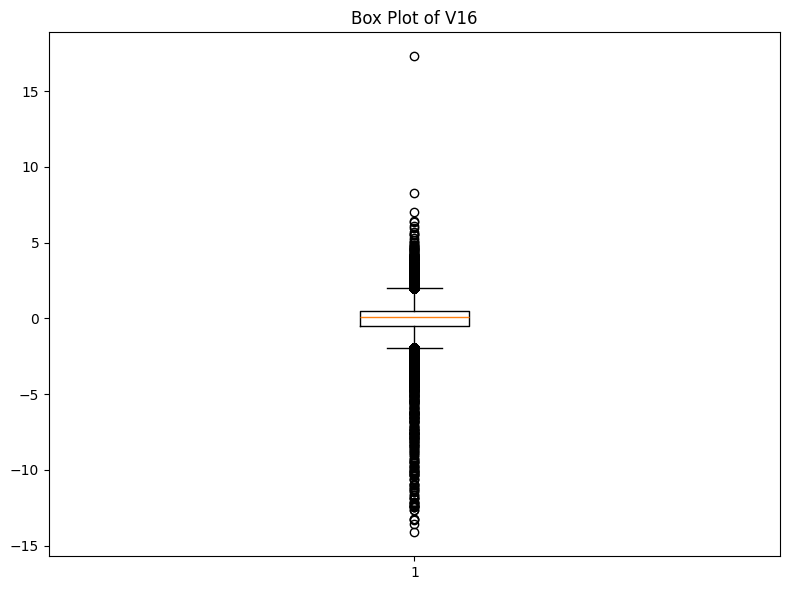

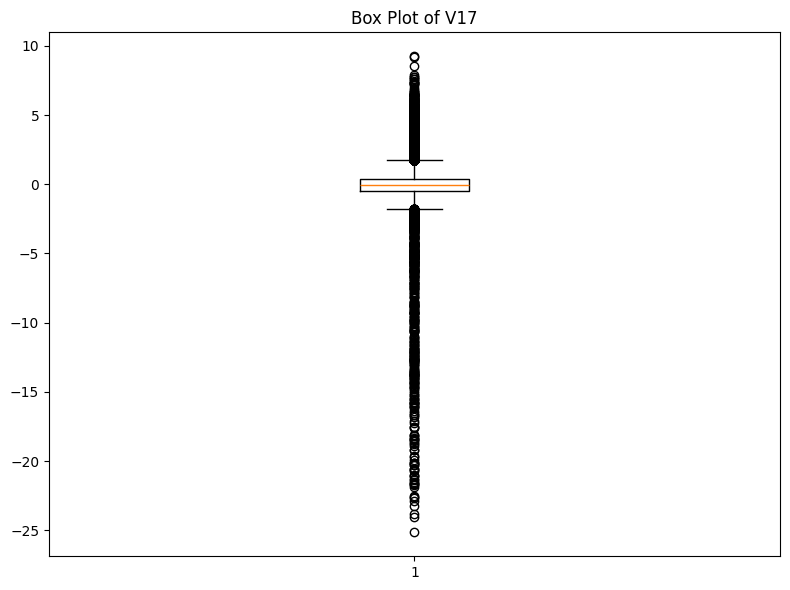

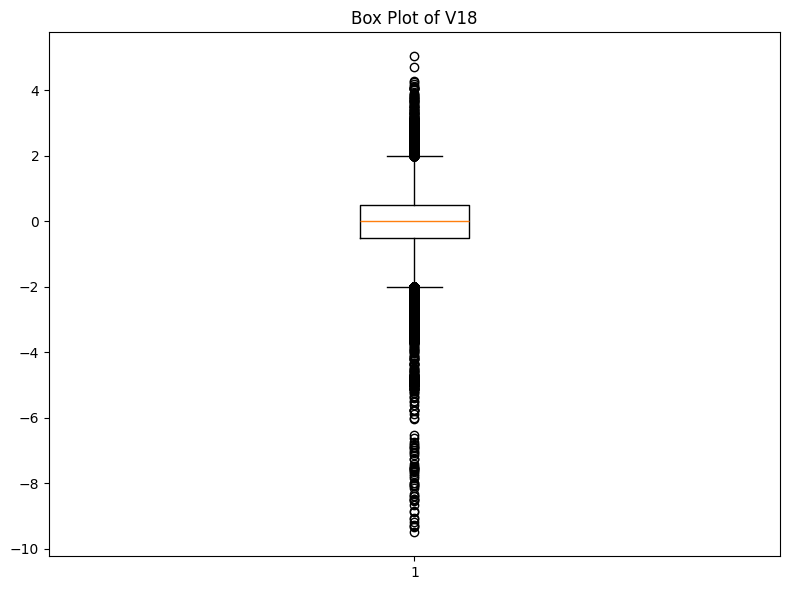

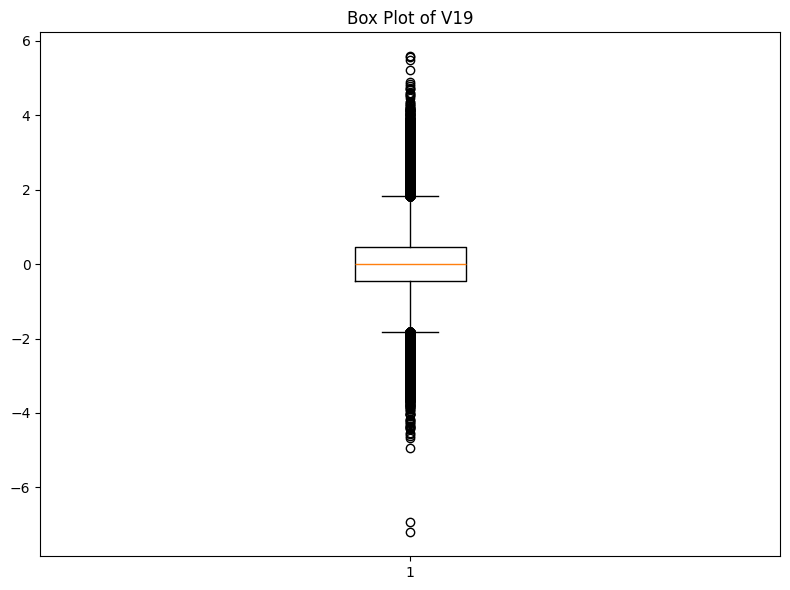

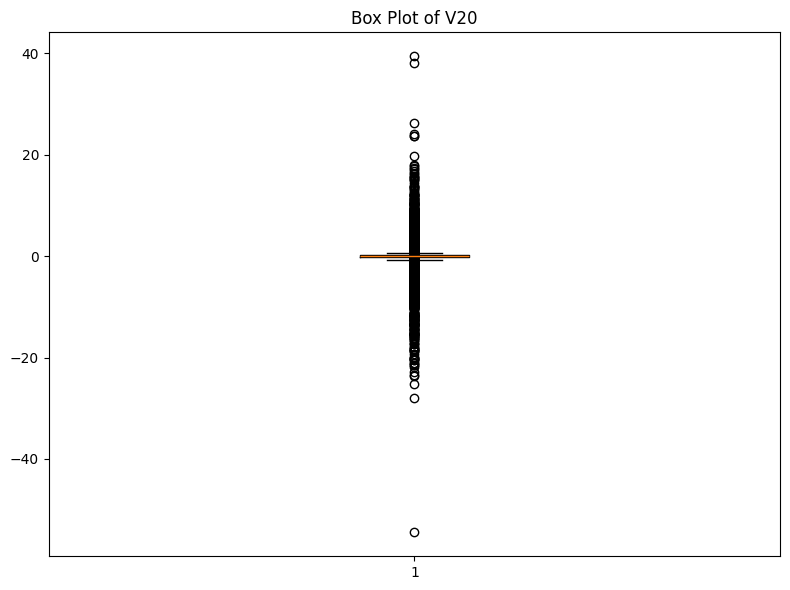

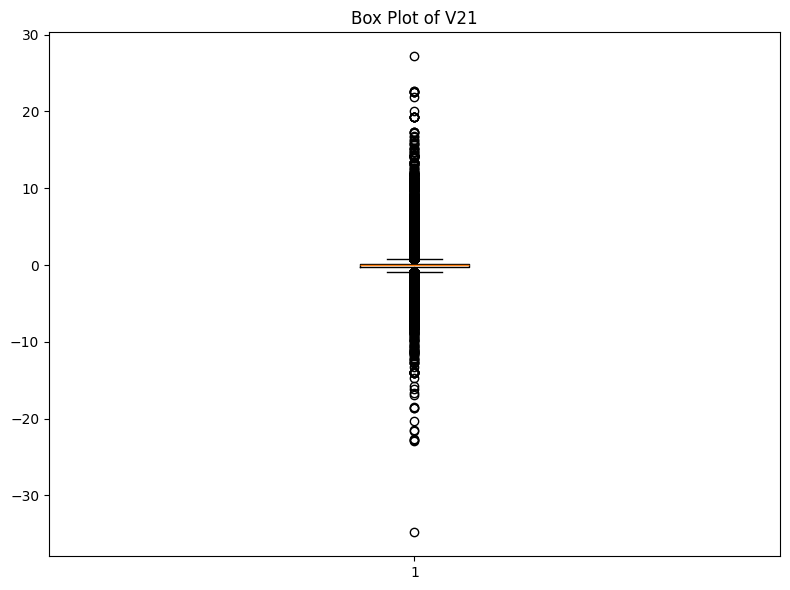

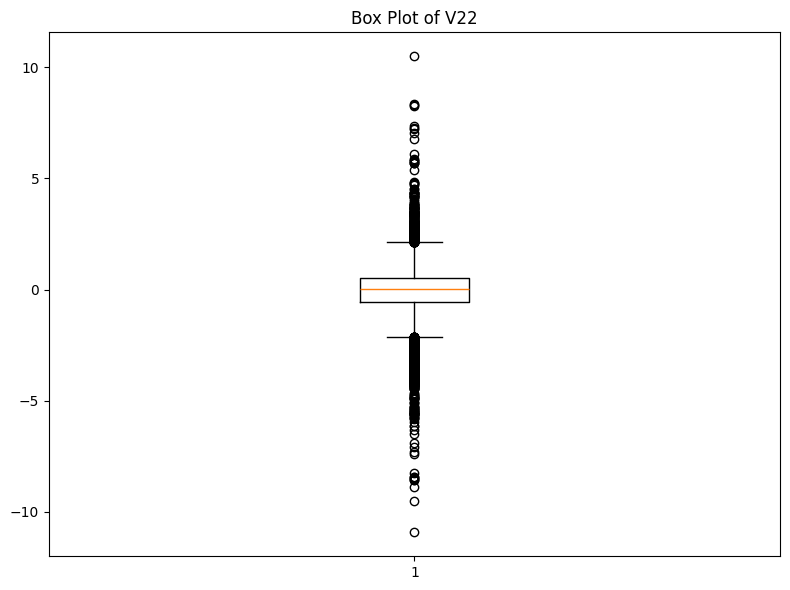

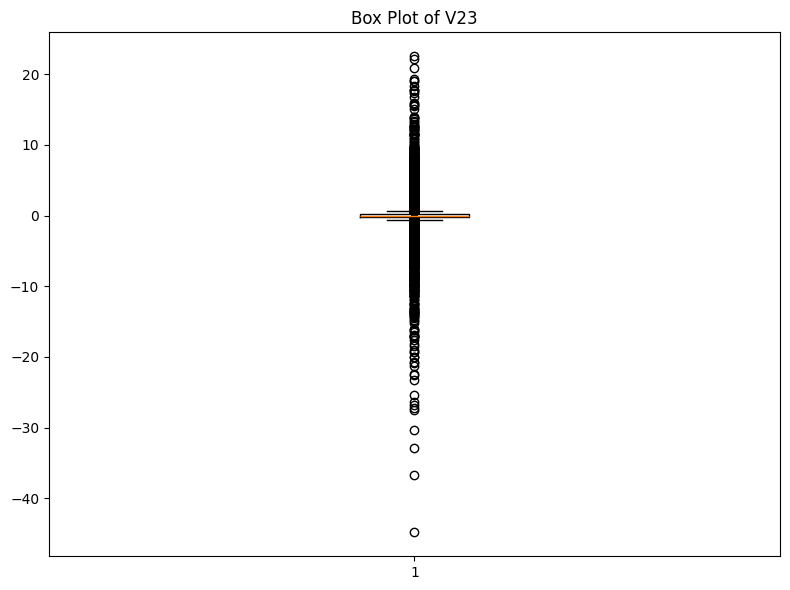

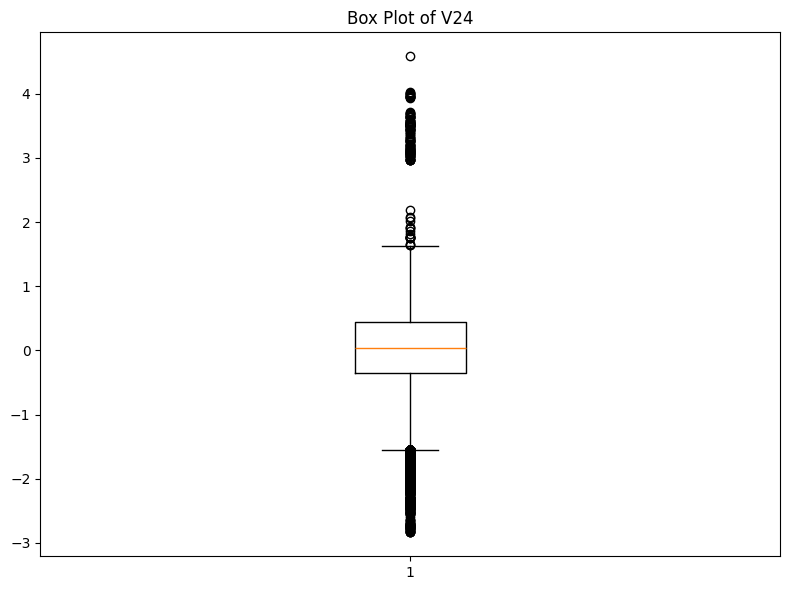

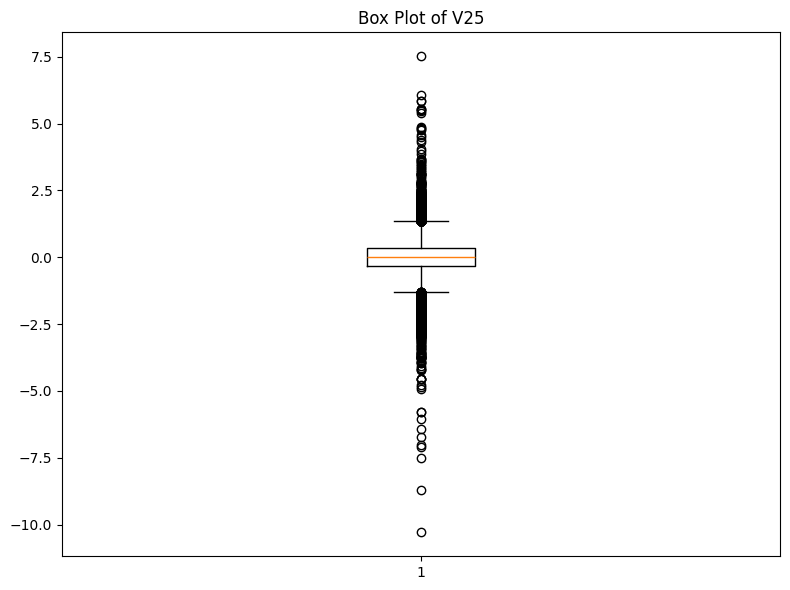

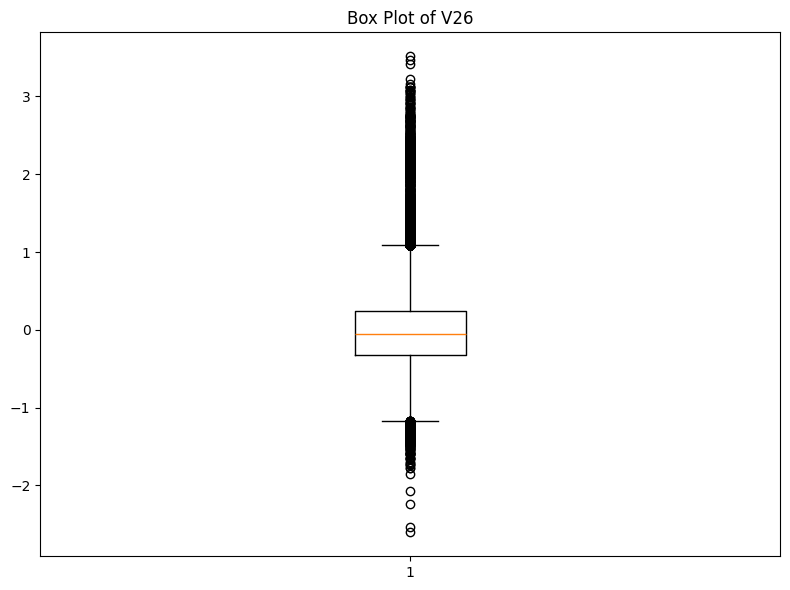

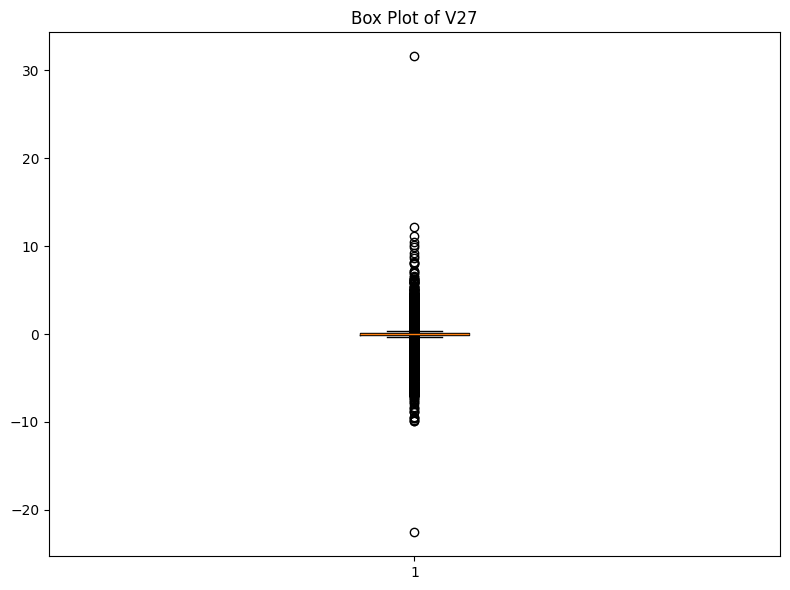

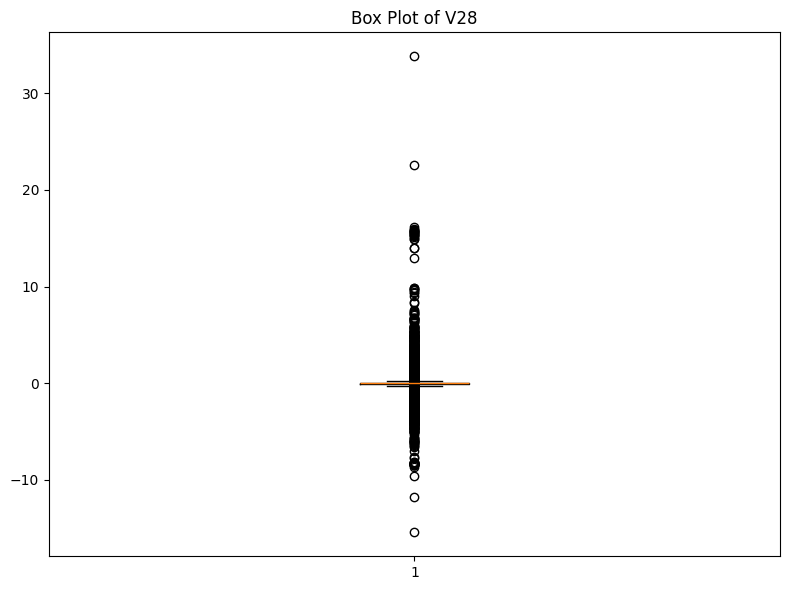

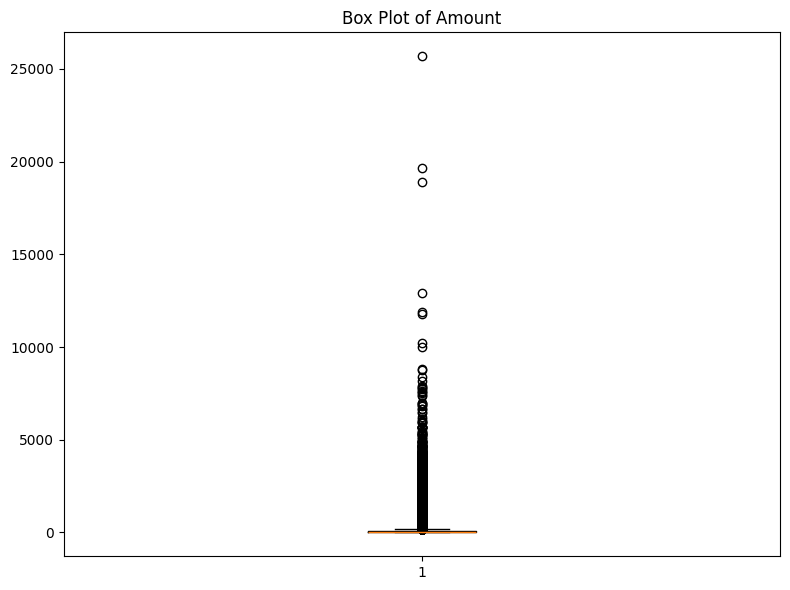

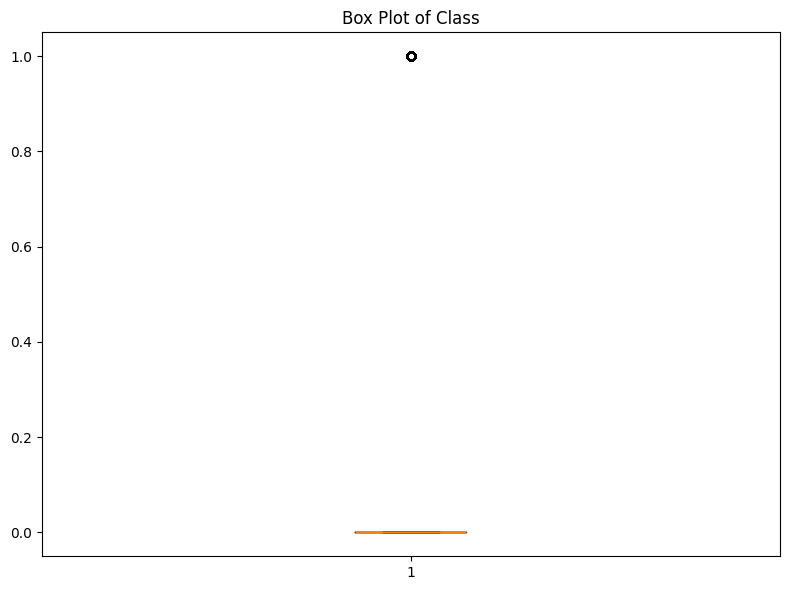

In [13]:
numeric_features = df.select_dtypes(include=['float64','int64'])
print(numeric_features.columns.to_list)

import matplotlib.pyplot as plt

# Box plot for all numeric features
for i, col in enumerate(numeric_features):
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()

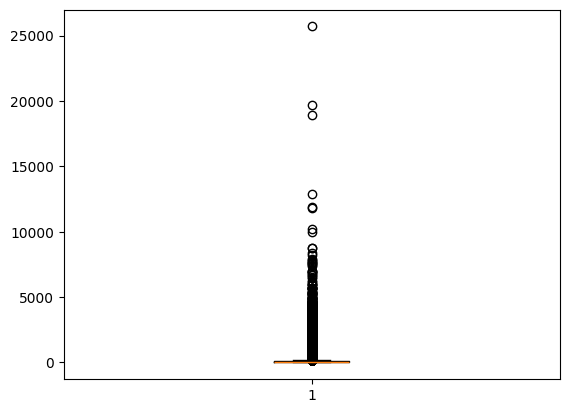

In [14]:
plt.boxplot(df['Amount'])
plt.show()

In [15]:
print('train test split')
print('-'*60)

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state=42,
    stratify =y
)
print('train ')

train test split
------------------------------------------------------------
train 


In [16]:
print('apply scaling')
print('-'*60)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nScaling done!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

apply scaling
------------------------------------------------------------

Scaling done!
X_train shape: (226980, 30)
X_test shape: (56746, 30)


In [17]:
print('tensor conversion')
print('-'*60)

import torch
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1,1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1,1)
print('done tensor conversation')

tensor conversion
------------------------------------------------------------
done tensor conversation


In [19]:
print('Custom dataset creation')
print('-'*60)
from torch.utils.data import Dataset,DataLoader

class CustomDataSet(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels.values, dtype=torch.float32).view(-1, 1)

  def __len__(self):
    return self.features.shape[0]
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

print('done creation')


Custom dataset creation
------------------------------------------------------------
done creation


In [ ]:
print('train Custom dataset')
print('-'*60)

train_dataset = CustomDataSet(X_train,y_train)
test_dataset = CustomDataSet(X_test,y_test)
print('done train dataset')

train Custom dataset
------------------------------------------------------------
done train dataset


In [ ]:
print('Applying Data loader')
print('-'*60)

from torch.utils.data import Dataset,DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

print('DONE ')

Applying Data loader / pin memmory for gpu
------------------------------------------------------------
DONE 


In [ ]:
print('Defining model')
print('-'*60)

class MySImpleNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,16),
        nn.ReLU(),
        nn.Linear(16,8),
        nn.ReLU(),
        nn.Linear(8,1),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.model(x)

print("DONE")


Defining model
------------------------------------------------------------
DONE


In [ ]:
print('parameter initialization')
print('-'*60)

epochs = 100
learning_rate = 0.001
cirterion = nn.BCELoss()

numeric_features = X_train.shape[1]
model = MySImpleNN(numeric_features)
optimizer = optim.Adam(model.parameters(),lr=learning_rate)

print('DONE!')


parameter initialization
------------------------------------------------------------
DONE!


In [ ]:
print('training loop')
print('-'*60)

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader:
    output = model(batch_features)
    loss = cirterion(output, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss =total_epoch_loss + loss.item()
avg_loss = total_epoch_loss / len(train_loader)
print(avg_loss)